In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (2).zip'  # change to your file
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: /content/dataset


In [ ]:
!find /content/dataset -maxdepth 2 -type d -print
# or list files
!ls -la /content/dataset

/content/dataset
/content/dataset/Bell Pepper
/content/dataset/Bell Pepper/Val
/content/dataset/Bell Pepper/Train
/content/dataset/Bell Pepper/Test
/content/dataset/Tomato
/content/dataset/Tomato/Val
/content/dataset/Tomato/Train
/content/dataset/Tomato/Test
/content/dataset/Cherry
/content/dataset/Cherry/Val
/content/dataset/Cherry/Train
/content/dataset/Cherry/Test
/content/dataset/Corn (Maize)
/content/dataset/Corn (Maize)/Val
/content/dataset/Corn (Maize)/Train
/content/dataset/Corn (Maize)/Test
/content/dataset/Peach
/content/dataset/Peach/Val
/content/dataset/Peach/Train
/content/dataset/Peach/Test
/content/dataset/Grape
/content/dataset/Grape/Val
/content/dataset/Grape/Train
/content/dataset/Grape/Test
/content/dataset/Strawberry
/content/dataset/Strawberry/Val
/content/dataset/Strawberry/Train
/content/dataset/Strawberry/Test
/content/dataset/Potato
/content/dataset/Potato/Val
/content/dataset/Potato/Train
/content/dataset/Potato/Test
/content/dataset/Apple
/content/dataset/App

In [ ]:
import os, shutil, zipfile

# ============================
# STEP 1: Unzip dataset from Drive
# ============================
zip_path = "/content/drive/MyDrive/archive (2).zip"
extract_path = "/content/original_dataset"

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)

# ============================
# STEP 2: Restructure dataset
# ============================
def restructure_dataset(root_path, target_path):
    os.makedirs(target_path, exist_ok=True)

    for plant in os.listdir(root_path):
        plant_path = os.path.join(root_path, plant)
        if not os.path.isdir(plant_path):
            continue

        for split in ["Train", "Val", "Test"]:  # handle capitalization
            split_path = os.path.join(plant_path, split)
            if not os.path.exists(split_path):
                continue

            for disease in os.listdir(split_path):
                disease_path = os.path.join(split_path, disease)
                if not os.path.isdir(disease_path):
                    continue

                # unique class name = Plant + Disease
                cls_name = f"{plant}{disease}".replace(" ", "").replace("(", "").replace(")", "")
                target_cls = os.path.join(target_path, split.lower(), cls_name)
                os.makedirs(target_cls, exist_ok=True)

                for file in os.listdir(disease_path):
                    src = os.path.join(disease_path, file)

                    # ✅ skip directories & hidden files
                    if os.path.isdir(src) or file.startswith('.'):
                        continue

                    dst = os.path.join(target_cls, file)
                    shutil.copy(src, dst)

# Run restructure
merged_path = "/content/merged_dataset"
restructure_dataset(extract_path, merged_path)

print("✅ Merged dataset ready at:", merged_path)
print("📂 Example Train classes:", os.listdir(os.path.join(merged_path, "train")))



✅ Dataset extracted to: /content/original_dataset
✅ Merged dataset ready at: /content/merged_dataset
📂 Example Train classes: ['PotatoEarlyBlight', 'CornMaizeNorthernLeafBlight', 'CherryPowderyMildew', 'StrawberryLeafScorch', 'TomatoEarlyBlight', 'TomatoBacterialSpot', 'AppleAppleScab', 'GrapeLeafBlight', 'GrapeEscaBlackMeasles', 'CornMaizeCommonRust', 'CherryHealthy', 'GrapeBlackRot', 'PotatoHealthy', 'TomatoHealthy', 'AppleCedarAppleRust', 'TomatoSeptoriaLeafSpot', 'GrapeHealthy', 'PotatoLateBlight', 'TomatoLateBlight', 'PeachBacterialSpot', 'TomatoYellowLeafCurlVirus', 'CornMaizeCercosporaLeafSpot', 'CornMaizeHealthy', 'StrawberryHealthy', 'BellPepperHealthy', 'BellPepperBacterialSpot', 'PeachHealthy', 'AppleHealthy', 'AppleBlackRot']


In [ ]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# ==============================
# STEP 2: Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# Folder to save models
save_dir = "/content/drive/MyDrive/plant_disease_models"
os.makedirs(save_dir, exist_ok=True)

# ==============================
# STEP 3: Setup Dataset Paths
# ==============================
train_dir = "/content/merged_dataset/train"
val_dir   = "/content/merged_dataset/val"
test_dir  = "/content/merged_dataset/test"

img_size = (300, 300)
batch_size = 32

# ==============================
# STEP 4: Load Dataset
# ==============================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size,
    shuffle=True, label_mode="categorical"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size,
    shuffle=True, label_mode="categorical"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size,
    shuffle=False, label_mode="categorical"
)

class_names = train_ds.class_names
print("✅ Classes:", class_names, "... total:", len(class_names))

# Prefetch and preprocess
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x,y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

# ==============================
# STEP 5: Data Augmentation
# ==============================
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
])

# ==============================
# STEP 6: Build Base Model
# ==============================
base_model = EfficientNetB3(
    weights="imagenet", include_top=False, input_shape=(300,300,3)
)
base_model.trainable = False  # freeze for initial training

inputs = layers.Input(shape=(300,300,3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==============================
# STEP 7: Initial Training (Frozen Base, 10 epochs)
# ==============================
frozen_checkpoint_path = os.path.join(save_dir, "best_model_b3_frozen1.keras")

callbacks_frozen = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint(frozen_checkpoint_path, save_best_only=True)
]

# Resume from checkpoint if exists
if os.path.exists(frozen_checkpoint_path):
    print("🔄 Loading frozen model checkpoint to resume training...")
    model.load_weights(frozen_checkpoint_path)

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=callbacks_frozen
)

# ==============================
# STEP 8: Fine-Tuning (Unfreeze last 100 layers, 15 epochs)
# ==============================
base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

finetune_checkpoint_path = os.path.join(save_dir, "best_model_b3_finetuned1.keras")

callbacks_finetune = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint(finetune_checkpoint_path, save_best_only=True)
]

# Resume from checkpoint if exists
if os.path.exists(finetune_checkpoint_path):
    print("🔄 Loading finetuned model checkpoint to resume training...")
    model.load_weights(finetune_checkpoint_path)

history_fine = model.fit(
    train_ds, validation_data=val_ds,
    epochs=15, callbacks=callbacks_finetune
)

# ==============================
# STEP 9: Evaluate on Test
# ==============================
test_loss, test_acc = model.evaluate(test_ds)
print("✅ Test Accuracy:", test_acc)

# ==============================
# STEP 10: Save Final Model
# ==============================
final_model_path = os.path.join(save_dir, "plant_disease_model_b3_final1.keras")
model.save(final_model_path)
print("💾 Final fine-tuned model saved at:", final_model_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 53690 files belonging to 29 classes.
Found 12067 files belonging to 29 classes.
Found 1354 files belonging to 29 classes.
✅ Classes: ['AppleAppleScab', 'AppleBlackRot', 'AppleCedarAppleRust', 'AppleHealthy', 'BellPepperBacterialSpot', 'BellPepperHealthy', 'CherryHealthy', 'CherryPowderyMildew', 'CornMaizeCercosporaLeafSpot', 'CornMaizeCommonRust', 'CornMaizeHealthy', 'CornMaizeNorthernLeafBlight', 'GrapeBlackRot', 'GrapeEscaBlackMeasles', 'GrapeHealthy', 'GrapeLeafBlight', 'PeachBacterialSpot', 'PeachHealthy', 'PotatoEarlyBlight', 'PotatoHealthy', 'PotatoLateBlight', 'StrawberryHealthy', 'StrawberryLeafScorch', 'TomatoBacterialSpot', 'TomatoEarlyBlight', 'TomatoHealthy', 'TomatoLateBlight', 'TomatoSeptoriaLeafSpot', 'TomatoYellowLeafCurlVirus'] ... total: 29
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │        44,573 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,828,108 (41.31 MB)

 Trainable params: 44,573 (174.11 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

Epoch 1/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 528s 302ms/step - accuracy: 0.7008 - loss: 1.1720 - val_accuracy: 0.9155 - val_loss: 0.3054
Epoch 2/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 503s 300ms/step - accuracy: 0.8970 - loss: 0.3462 - val_accuracy: 0.9351 - val_loss: 0.2212
Epoch 3/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 561s 300ms/step - accuracy: 0.9097 - loss: 0.2816 - val_accuracy: 0.9439 - val_loss: 0.1855
Epoch 4/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 501s 298ms/step - accuracy: 0.9165 - loss: 0.2641 - val_accuracy: 0.9484 - val_loss: 0.1644
Epoch 5/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 502s 299ms/step - accuracy: 0.9196 - loss: 0.2514 - val_accuracy: 0.9514 - val_loss: 0.1550
Epoch 6/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 503s 300ms/step - accuracy: 0.9169 - loss: 0.2457 - val_accuracy: 0.9533 - val_loss: 0.1475
Epoch 7/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 503s 300ms/step - accuracy: 0.9208 - loss: 0.2363 - val_accuracy: 0.9556 - val_loss: 0.1343
Epoch 8/10
1678/1678 ━━━━━━━━━━━━━━━━━━━━ 561s 299ms/step - ac

In [ ]:
# ==============================
# Prediction with File Upload
# ==============================
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from google.colab import files

# ==============================
# STEP 1: Load Model
# ==============================
model_path = "/content/drive/MyDrive/plant_disease_models/plant_disease_model_b3_final1.keras"
model = tf.keras.models.load_model(model_path)

# ==============================
# STEP 2: Get Class Names from Train Directory
# ==============================
train_dir = "/content/merged_dataset/train"
class_names = sorted(os.listdir(train_dir))  # alphabetically same as training
print("✅ Classes Loaded:", class_names)

# ==============================
# STEP 3: Upload Image
# ==============================
uploaded = files.upload()
img_path = list(uploaded.keys())[0]   # first uploaded file

# ==============================
# STEP 4: Prediction Function
# ==============================
def predict_disease(img_path):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(300, 300))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Predict
    preds = model.predict(img_array)
    predicted_index = np.argmax(preds, axis=1)[0]
    predicted_class = class_names[predicted_index]
    confidence = np.max(preds)

    return predicted_class, confidence

# ==============================
# STEP 5: Run Prediction
# ==============================
pred_class, conf = predict_disease(img_path)
print(f"🌱 Predicted Disease: {pred_class} (confidence: {conf:.2f})")

✅ Classes Loaded: ['AppleAppleScab', 'AppleBlackRot', 'AppleCedarAppleRust', 'AppleHealthy', 'BellPepperBacterialSpot', 'BellPepperHealthy', 'CherryHealthy', 'CherryPowderyMildew', 'CornMaizeCercosporaLeafSpot', 'CornMaizeCommonRust', 'CornMaizeHealthy', 'CornMaizeNorthernLeafBlight', 'GrapeBlackRot', 'GrapeEscaBlackMeasles', 'GrapeHealthy', 'GrapeLeafBlight', 'PeachBacterialSpot', 'PeachHealthy', 'PotatoEarlyBlight', 'PotatoHealthy', 'PotatoLateBlight', 'StrawberryHealthy', 'StrawberryLeafScorch', 'TomatoBacterialSpot', 'TomatoEarlyBlight', 'TomatoHealthy', 'TomatoLateBlight', 'TomatoSeptoriaLeafSpot', 'TomatoYellowLeafCurlVirus']


Saving test4.jpeg to test4.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
🌱 Predicted Disease: AppleCedarAppleRust (confidence: 0.61)


Found 1354 files belonging to 29 classes.
✅ Test Classes: ['AppleAppleScab', 'AppleBlackRot', 'AppleCedarAppleRust', 'AppleHealthy', 'BellPepperBacterialSpot', 'BellPepperHealthy', 'CherryHealthy', 'CherryPowderyMildew', 'CornMaizeCercosporaLeafSpot', 'CornMaizeCommonRust', 'CornMaizeHealthy', 'CornMaizeNorthernLeafBlight', 'GrapeBlackRot', 'GrapeEscaBlackMeasles', 'GrapeHealthy', 'GrapeLeafBlight', 'PeachBacterialSpot', 'PeachHealthy', 'PotatoEarlyBlight', 'PotatoHealthy', 'PotatoLateBlight', 'StrawberryHealthy', 'StrawberryLeafScorch', 'TomatoBacterialSpot', 'TomatoEarlyBlight', 'TomatoHealthy', 'TomatoLateBlight', 'TomatoSeptoriaLeafSpot', 'TomatoYellowLeafCurlVirus'] ... total: 29
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 316ms/step
📊 Classification Report:
                             precision    recall  f1-score   support

             AppleAppleScab       1.00      1.00      1.00        51
              AppleBlackRot       1.00      1.00      1.00        50
        AppleCedarAppleRust    

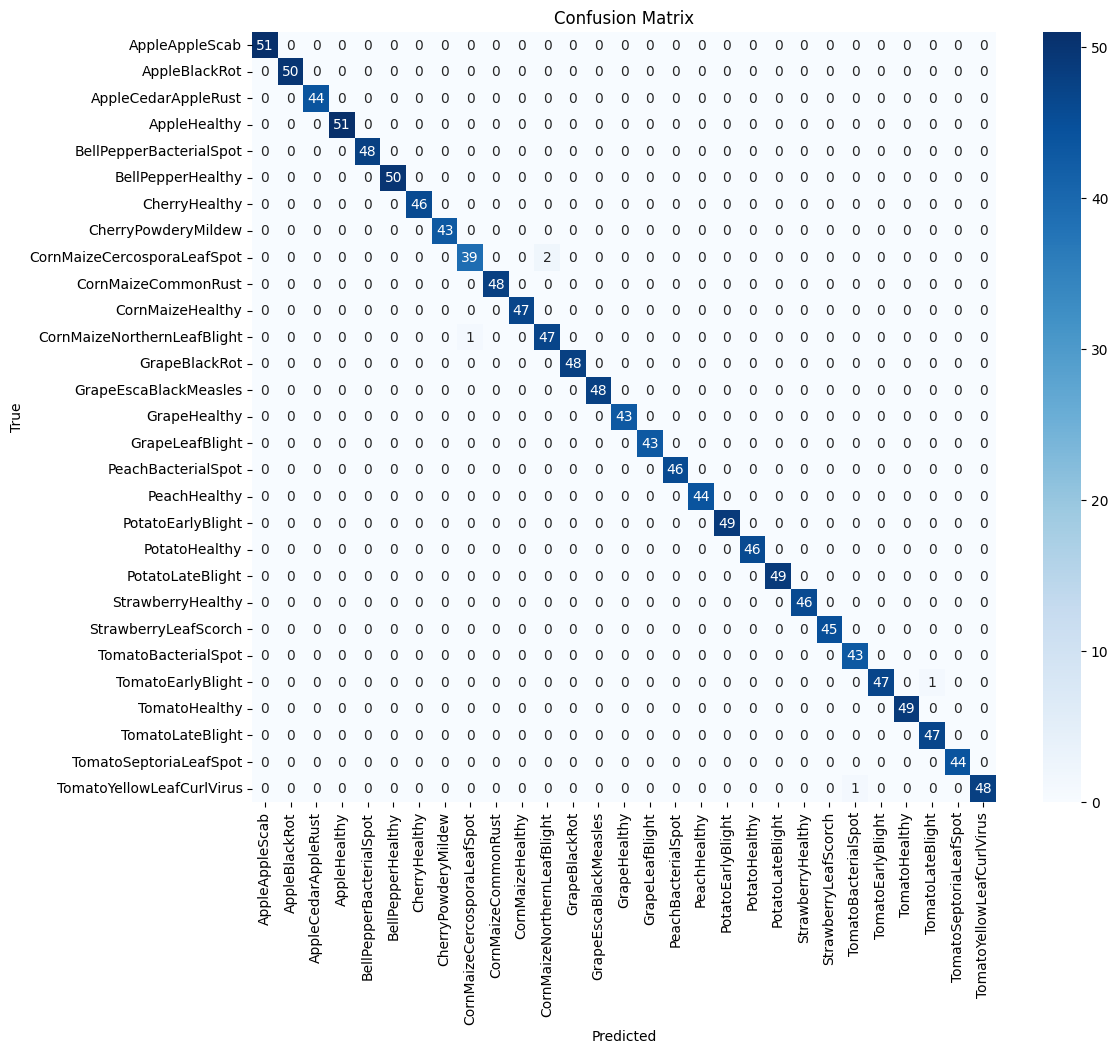

In [ ]:
# ==============================
# STEP 1: Reload Test Dataset
# ==============================
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Path to test dataset
test_dir = "/content/merged_dataset/test"
img_size = (300, 300)
batch_size = 32

# Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,            # 🚨 Important: keep order for evaluation
    label_mode="categorical"
)

class_names = test_ds.class_names
print("✅ Test Classes:", class_names, "... total:", len(class_names))

# Preprocess test data (same as training)
from tensorflow.keras.applications.efficientnet import preprocess_input
AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

# ==============================
# STEP 2: Load Trained Model
# ==============================
model_path = "/content/drive/MyDrive/plant_disease_models/plant_disease_model_b3_final1.keras"
model = load_model(model_path)

# ==============================
# STEP 3: Predictions
# ==============================
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_pred = model.predict(test_ds)
y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# ==============================
# STEP 4: Classification Report
# ==============================
print("📊 Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# ==============================
# STEP 5: Confusion Matrix
# ==============================
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()